In [2]:
%pip install -q xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Load datasets
df = pd.read_csv('https://api.vitaldb.net/cases')
df['sex'] = (df['sex'] == 'M')

# Load labs
df_labs = pd.read_csv('https://api.vitaldb.net/labs')
df_labs = df_labs.loc[df_labs.name == 'cr']

# postop creatinine level within 7 days after surgery
df_labs = pd.merge(df, df_labs, on='caseid', how='left')
df_labs = df_labs.loc[df_labs.dt > df_labs.opend]
df_labs = df_labs.loc[df_labs.dt < df_labs.opend + 7 * 3600 * 24]
df_labs = df_labs.groupby('caseid')['result'].max().reset_index()
df_labs.groupby('caseid')['result'].max().reset_index()
df_labs.rename(columns={'result':'postop_cr'}, inplace=True)

df = pd.merge(df, df_labs, on='caseid', how='left')
df.dropna(subset=['preop_cr', 'postop_cr'], inplace=True)

df

,caseid,subjectid,casestart,caseend,anestart,aneend,opstart,opend,adm,dis,...,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca,postop_cr
0,1,5955,0,11542,-552,10848.0,1668,10368,-236220,627780,...,120,0.0,100,70,0,10,0,0,0,0.91
1,2,2487,0,15741,-1039,14921.0,1721,14621,-221160,1506840,...,150,0.0,0,100,0,20,0,0,0,1.02
3,4,1903,0,20990,-778,20222.0,2522,17822,-201120,576480,...,80,0.0,100,100,0,50,0,0,0,0.87
4,5,4416,0,21531,-1009,22391.0,2591,20291,-67560,3734040,...,0,0.0,0,160,0,10,900,0,2100,4.43
9,10,2175,0,20992,-1743,21057.0,2457,19857,-220740,3580860,...,90,0.0,0,110,0,20,500,0,600,1.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6382,6383,4255,0,23242,-1883,23137.0,3037,22641,-224040,812760,...,0,0.0,0,80,0,10,0,0,300,6.14
6383,6384,5583,0,15248,-260,15640.0,2140,14140,-215340,648660,...,150,0.0,0,90,0,20,0,0,0,1.07
6384,6385,2278,0,20643,-544,20996.0,2396,19496,-225600,1675200,...,100,0.0,0,100,0,25,30,0,300,1.14
6385,6386,4045,0,19451,-667,19133.0,3533,18233,-200460,836340,...,70,0.0,0,130,0,10,0,0,0,0.62


In [4]:
# Remove categorical variables
df = df.drop(columns=['department','optype', 'dx', 'opname', 'approach', 'position', 'ane_type', 'cormack', 'airway', 'tubesize', 'dltubesize', 'lmasize', 'lmasize', 'preop_ecg', 'preop_pft', 'iv1', 'iv2', 'aline1', 'aline2', 'cline1', 'cline2'])
df = df.astype(float)

# KDIGO stage I
df['aki'] = df['postop_cr'] > df['preop_cr'] * 1.5

# Remove outcome variables
y = df['aki'].values.flatten()
df['andur'] = df['aneend'] - df['anestart']
df = df.drop(columns=['aki', 'postop_cr', 'death_inhosp','caseid','subjectid','icu_days','casestart','caseend','anestart','aneend','opstart','opend','adm','dis'])

# Input variables
x = df.values

x

array([[7.700e+01, 1.000e+00, 1.602e+02, ..., 0.000e+00, 0.000e+00,
        1.140e+04],
       [5.400e+01, 1.000e+00, 1.673e+02, ..., 0.000e+00, 0.000e+00,
        1.596e+04],
       [7.400e+01, 1.000e+00, 1.606e+02, ..., 0.000e+00, 0.000e+00,
        2.100e+04],
       ...,
       [6.900e+01, 1.000e+00, 1.593e+02, ..., 0.000e+00, 3.000e+02,
        2.154e+04],
       [6.100e+01, 0.000e+00, 1.517e+02, ..., 0.000e+00, 0.000e+00,
        1.980e+04],
       [2.400e+01, 0.000e+00, 1.557e+02, ..., 0.000e+00, 0.000e+00,
        1.338e+04]])

In [5]:
# Split a dataset into train and test sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# Print the number of train and test sets
print(f'{sum(y_train)}/{len(y_train)} ({np.mean(y_train)*100:.2f}%) train, {sum(y_test)}/{len(y_test)} ({np.mean(y_test)*100:.2f}%) test, {x_train.shape[1]} features', flush=True)

# Gradient Boosting Machine
from xgboost import XGBClassifier
model = XGBClassifier(max_depth=4, n_estimators=50, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss')
model.fit(x_train, y_train)
y_pred_gbm = model.predict_proba(x_test)[:, 1]

166/3191 (5.20%) train, 44/798 (5.51%) test, 43 features


In [14]:
from sklearn.model_selection import GridSearchCV

xgb_base = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',   
    cv=3,                
    verbose=1,
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print(f"Best parameters:", grid_search.best_params_)
print(f"Best AUC: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits


c:\Users\DELL\anaconda3\envs\nlp-teddy\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:36:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best AUC: 0.8164


In [15]:
best_xgb = grid_search.best_estimator_
best_xgb.fit(x_train, y_train)
y_pred_best = best_xgb.predict_proba(x_test)[:, 1]

print("Test AUC:", roc_auc_score(y_test, y_pred_best))

c:\Users\DELL\anaconda3\envs\nlp-teddy\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:37:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test AUC: 0.8463648420544972


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Xử lý dữ liệu thiếu (NaN)
imputer = SimpleImputer(strategy='mean')
x_train_imp = imputer.fit_transform(x_train)
x_test_imp = imputer.transform(x_test)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_imp)
x_test_scaled = scaler.transform(x_test_imp)

# Huấn luyện Logistic Regression
model_lr = LogisticRegression(max_iter=1000, solver='lbfgs')
model_lr.fit(x_train_scaled, y_train)

# Dự đoán
y_pred_lr = model_lr.predict(x_test_scaled)
y_pred_lr_proba = model_lr.predict_proba(x_test_scaled)[:, 1]  # ✅ đây chính là biến cần dùng

# Kiểm tra sơ bộ kết quả
from sklearn.metrics import accuracy_score, roc_auc_score
print(f" Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f" Logistic Regression AUC: {roc_auc_score(y_test, y_pred_lr_proba):.4f}")

 Logistic Regression Accuracy: 0.9499
 Logistic Regression AUC: 0.7085


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.impute import SimpleImputer

# Xử lý giá trị thiếu (NaN)
imputer = SimpleImputer(strategy='mean')
x_train_imp = imputer.fit_transform(x_train)
x_test_imp = imputer.transform(x_test)

# Khởi tạo mô hình Random Forest
model_rf = RandomForestClassifier(
    n_estimators=200,      # số cây (có thể tăng để chính xác hơn)
    max_depth=None,        # không giới hạn độ sâu
    min_samples_split=2,   # chia khi còn >= 2 mẫu
    random_state=42,
    n_jobs=-1              # dùng hết CPU cores
)

# Huấn luyện mô hình
model_rf.fit(x_train_imp, y_train)

# Dự đoán
y_pred_rf = model_rf.predict(x_test_imp)
y_pred_rf_proba = model_rf.predict_proba(x_test_imp)[:, 1]

# Đánh giá kết quả
acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_pred_rf_proba)

print(f" Random Forest Accuracy: {acc_rf:.4f}")
print(f" Random Forest AUC: {auc_rf:.4f}")

 Random Forest Accuracy: 0.9449
 Random Forest AUC: 0.8325


In [18]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,      
    cv=3,
    scoring='roc_auc',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(x_train_imp, y_train)
print("Best params:", rf_random.best_params_)
print("Best AUC (CV):", rf_random.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}
Best AUC (CV): 0.7978739088574233


In [9]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.impute import SimpleImputer

# Xử lý dữ liệu thiếu
imputer = SimpleImputer(strategy='mean')
x_train_imp = imputer.fit_transform(x_train)
x_test_imp = imputer.transform(x_test)

# Cây quyết định cơ sở (base learner)
base_tree = DecisionTreeClassifier(max_depth=None, random_state=42)

# Mô hình Bagging
model_bag = BaggingClassifier(
    estimator=base_tree,  # mô hình cơ sở
    n_estimators=100,          # số lượng mô hình con
    max_samples=0.8,           # mỗi mô hình dùng 80% dữ liệu huấn luyện (bootstrap)
    max_features=0.8,          # chọn ngẫu nhiên 80% đặc trưng
    random_state=42,
    n_jobs=-1
)

# Huấn luyện mô hình
model_bag.fit(x_train_imp, y_train)

# Dự đoán
y_pred_bag = model_bag.predict(x_test_imp)
y_pred_bag_proba = model_bag.predict_proba(x_test_imp)[:, 1]

# Đánh giá kết quả
acc_bag = accuracy_score(y_test, y_pred_bag)
auc_bag = roc_auc_score(y_test, y_pred_bag_proba)

print(f" Bagging Accuracy: {acc_bag:.4f}")
print(f" Bagging AUC: {auc_bag:.4f}")

 Bagging Accuracy: 0.9424
 Bagging AUC: 0.8434


In [22]:
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()
model_nb.fit(x_train_imp, y_train)

y_pred_nb = model_nb.predict(x_test_imp)
y_pred_nb_proba = model_nb.predict_proba(x_test_imp)[:, 1]

acc_nb = accuracy_score(y_test, y_pred_nb)
auc_nb = roc_auc_score(y_test, y_pred_nb_proba)

print(f"Naive Bayes Accuracy: {acc_nb:.4f}")
print(f"Naive Bayes AUC: {auc_nb:.4f}")


Naive Bayes Accuracy: 0.0564
Naive Bayes AUC: 0.5247


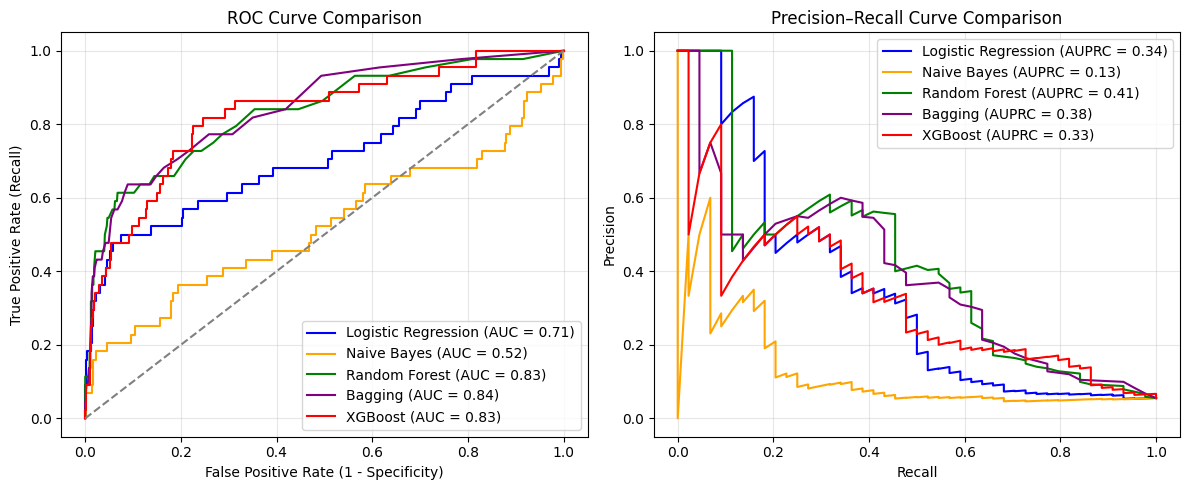

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

models = {
    "Logistic Regression": (y_pred_lr_proba, "blue"),
    "Naive Bayes": (y_pred_nb_proba, "orange"),
    "Random Forest": (y_pred_rf_proba, "green"),
    "Bagging": (y_pred_bag_proba, "purple"),
    "XGBoost": (y_pred_gbm, "red")
}

plt.figure(figsize=(12, 5))

# === ROC Curve ===
plt.subplot(1, 2, 1)
for name, (y_score, color) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()
plt.grid(alpha=0.3)

# === Precision-Recall Curve ===
plt.subplot(1, 2, 2)
for name, (y_score, color) in models.items():
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    pr_auc = average_precision_score(y_test, y_score)
    plt.plot(recall, precision, color=color, label=f"{name} (AUPRC = {pr_auc:.2f})")

plt.title("Precision–Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

GBM AUROC: 0.827, AUPRC: 0.319


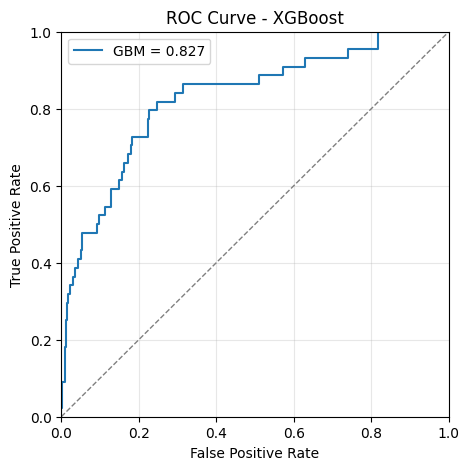

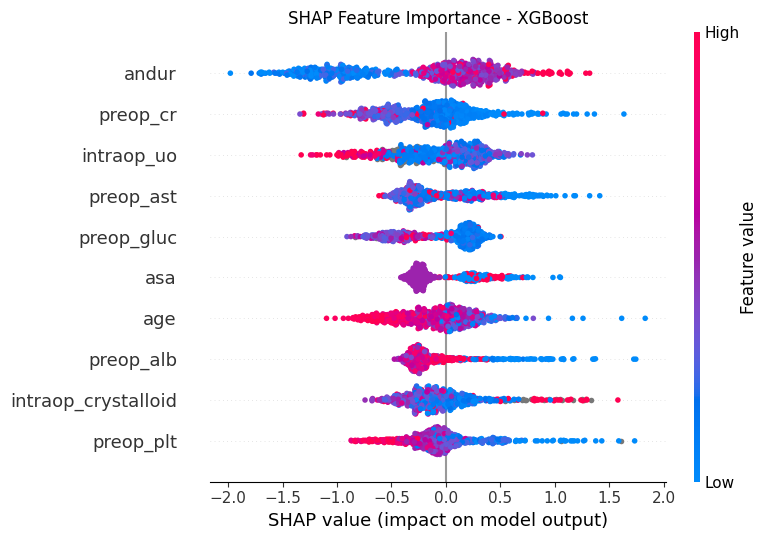

In [27]:
import shap

auroc_gbm = roc_auc_score(y_test, y_pred_gbm)
prc_gbm, rec_gbm, thresholds = precision_recall_curve(y_test, y_pred_gbm)
auprc_gbm = auc(rec_gbm, prc_gbm)
fpr_gbm, tpr_gbm, _ = roc_curve(y_test, y_pred_gbm)

print(f"GBM AUROC: {auroc_gbm:.3f}, AUPRC: {auprc_gbm:.3f}")

# ROC
plt.figure(figsize=(5, 5))
plt.plot(fpr_gbm, tpr_gbm, label=f"GBM = {auroc_gbm:.3f}")
plt.plot([0, 1], [0, 1], lw=1, linestyle="--", color="gray")
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("auroc.png", dpi=300)
plt.show()

# SHAP
explainer = shap.TreeExplainer(model) 
shap_values = explainer.shap_values(x_test)

plt.figure(figsize=(7, 5))
shap.summary_plot(
    shap_values,
    x_test,
    feature_names=df.columns,
    show=False,
    max_display=10  # chỉ hiển thị top 10 đặc trưng
)
plt.title("SHAP Feature Importance - XGBoost")
plt.tight_layout()
plt.savefig("shap.png", dpi=300)
plt.show()

# TRUC QUAN HOA DU LIEU 
Xây dựng mô hình dự đoán tổn thương thận cấp (AKI) sau phẫu thuật dựa trên dữ liệu bệnh nhân gây mê – hồi sức từ VitalDB.
Mục tiêu cụ thể:

Nhận diện sớm bệnh nhân có nguy cơ AKI.

So sánh hiệu suất giữa các thuật toán học máy phổ biến (Logistic Regression, Naive Bayes, Random Forest, Bagging, XGBoost).

Phân tích các yếu tố ảnh hưởng chính đến nguy cơ AKI.

Gồm 2 bảng chính:
- cases: Thông tin bệnh nhân & ca mổ.
- labs: Kết quả xét nghiệm sinh hóa (đặc biệt là creatinine - “cr”).

Biến đầu vào (Independent variables):
- Tiền phẫu (Pre-op): age, sex, asa, preop_cr, preop_htn, preop_dm, preop_hb, preop_alb,...
- Trong mổ (Intra-op): intraop_ebl, intraop_uo, intraop_rbc, intraop_crystalloid, intraop_colloid,...

Thông tin chung: bmi, andur (thời lượng gây mê).

Biến đầu ra (Dependent variable):
- aki: xác định theo tiêu chuẩn KDIGO stage I
- aki = postop_cr > preop_cr * 1.5

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

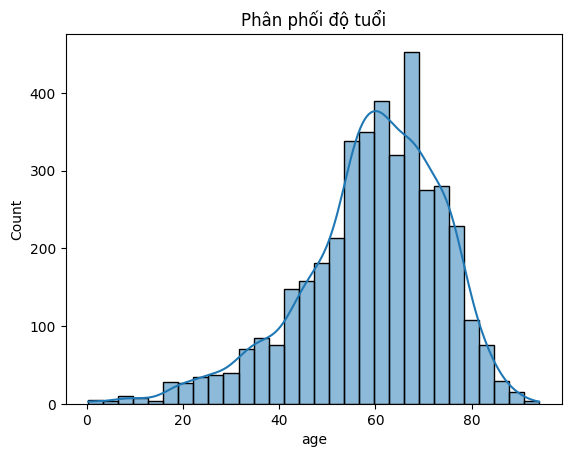

In [32]:
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Phân phối độ tuổi")
plt.show()

In [34]:
print(df.columns.tolist())

['age', 'sex', 'height', 'weight', 'bmi', 'asa', 'emop', 'preop_htn', 'preop_dm', 'preop_hb', 'preop_plt', 'preop_pt', 'preop_aptt', 'preop_na', 'preop_k', 'preop_gluc', 'preop_alb', 'preop_ast', 'preop_alt', 'preop_bun', 'preop_cr', 'preop_ph', 'preop_hco3', 'preop_be', 'preop_pao2', 'preop_paco2', 'preop_sao2', 'intraop_ebl', 'intraop_uo', 'intraop_rbc', 'intraop_ffp', 'intraop_crystalloid', 'intraop_colloid', 'intraop_ppf', 'intraop_mdz', 'intraop_ftn', 'intraop_rocu', 'intraop_vecu', 'intraop_eph', 'intraop_phe', 'intraop_epi', 'intraop_ca', 'andur']


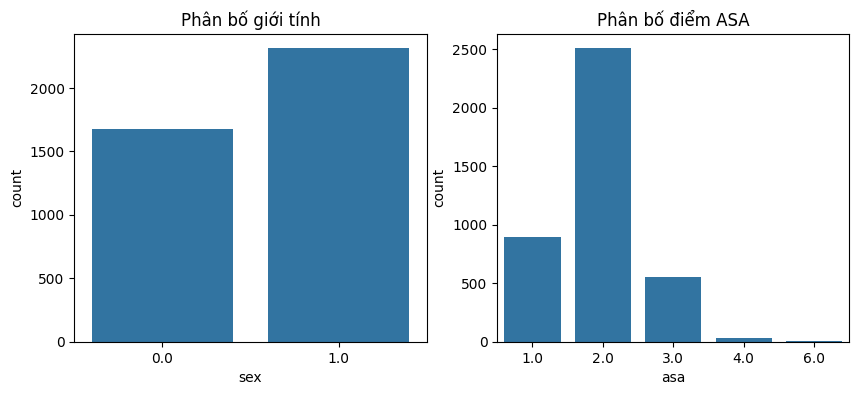

In [40]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.countplot(x='sex', data=df)
plt.title('Phân bố giới tính')

plt.subplot(1,2,2)
sns.countplot(x='asa', data=df)
plt.title('Phân bố điểm ASA')
plt.show()

Nam chiếm đa số (~60–70%).
Phần lớn bệnh nhân có ASA 2–3 (thể trạng trung bình đến yếu).

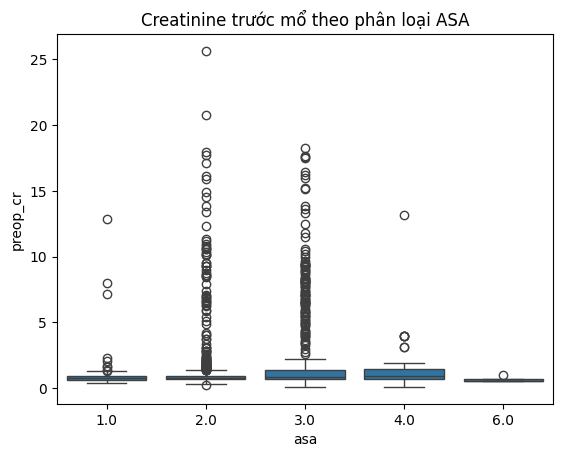

In [42]:
sns.boxplot(x='asa', y='preop_cr', data=df)
plt.title("Creatinine trước mổ theo phân loại ASA")
plt.show()

Trục hoành (x): phân loại ASA (từ 1 đến 6, trong dữ liệu của bạn có 1–4 và 6).
Trục tung (y): giá trị creatinine trước mổ (preop_cr) — chỉ số chức năng thận.
Hộp (box): thể hiện phân bố trung vị (median), tứ phân vị (IQR) và ngoại lệ (outliers).

# Mức độ trung bình & xu hướng

Trung vị của preop_cr có xu hướng tăng nhẹ khi ASA tăng (đặc biệt từ ASA 2 → 3).
Điều này gợi ý rằng bệnh nhân có tình trạng nặng hơn (ASA cao) thường đi kèm với chức năng thận kém hơn, phù hợp với logic lâm sàng.

# Độ phân tán và ngoại lệ

Tất cả nhóm ASA đều có nhiều giá trị ngoại lệ cao (outliers trên 5 mg/dL), đặc biệt ở ASA 2–3.

# Nhóm ASA 1 và ASA 4 có độ phân tán thấp hơn, cho thấy nhóm này ít bệnh nhân hoặc tương đối đồng nhất.

Các hộp đều bị kéo lệch lên trên → phân bố lệch phải (right-skewed), nghĩa là phần lớn bệnh nhân có creatinine thấp, chỉ một số nhỏ cao bất thường.

# Nhóm ASA 6

Số lượng ít (ít điểm dữ liệu) → có thể là bệnh nhân hiến tạng chết não, thường được mã hóa ASA 6.

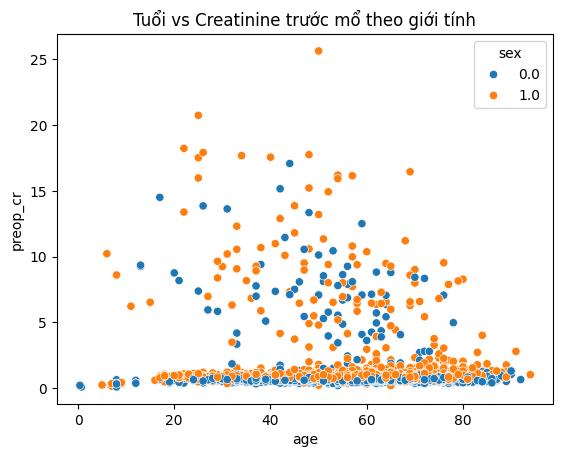

In [39]:
sns.scatterplot(x='age', y='preop_cr', hue='sex', data=df)
plt.title("Tuổi vs Creatinine trước mổ theo giới tính")
plt.show()

# Mối quan hệ giữa tuổi và creatinine
+ Không có xu hướng tuyến tính rõ ràng giữa tuổi và creatinine: creatinine dao động trong toàn bộ các độ tuổi.
+ Tuy nhiên, có xu hướng nhẹ tăng ở nhóm tuổi trung niên – cao tuổi (40–70 tuổi), phản ánh sự giảm dần chức năng thận theo tuổi.
+ Ở nhóm trẻ (<30 tuổi), creatinine hầu hết <1.0 mg/dL → chức năng thận tốt.

# Khác biệt giữa giới tính
+ Nam có giá trị creatinine cao hơn so với Nữ
+ Cả hai giới đều có một số ngoại lệ cao (>10 mg/dL), có thể là bệnh nhân suy thận hoặc cấp cứu.

# Outliers
+ Có khá nhiều điểm nằm xa trục tung (creatinine >5 mg/dL) ở độ tuổi 40–70 → nhóm bệnh nhân có nguy cơ cao, cần theo dõi kỹ trong mổ.

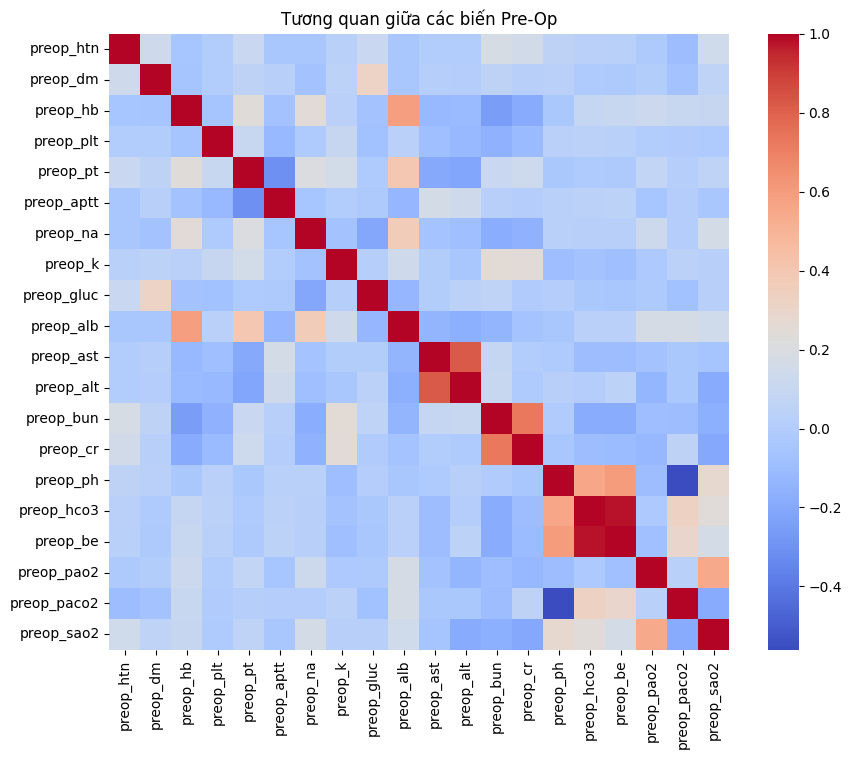

In [48]:
preop_cols = [col for col in df.columns if col.startswith('preop')]
plt.figure(figsize=(10,8))
sns.heatmap(df[preop_cols].corr(), cmap='coolwarm', annot=False)
plt.title("Tương quan giữa các biến Pre-Op")
plt.show()


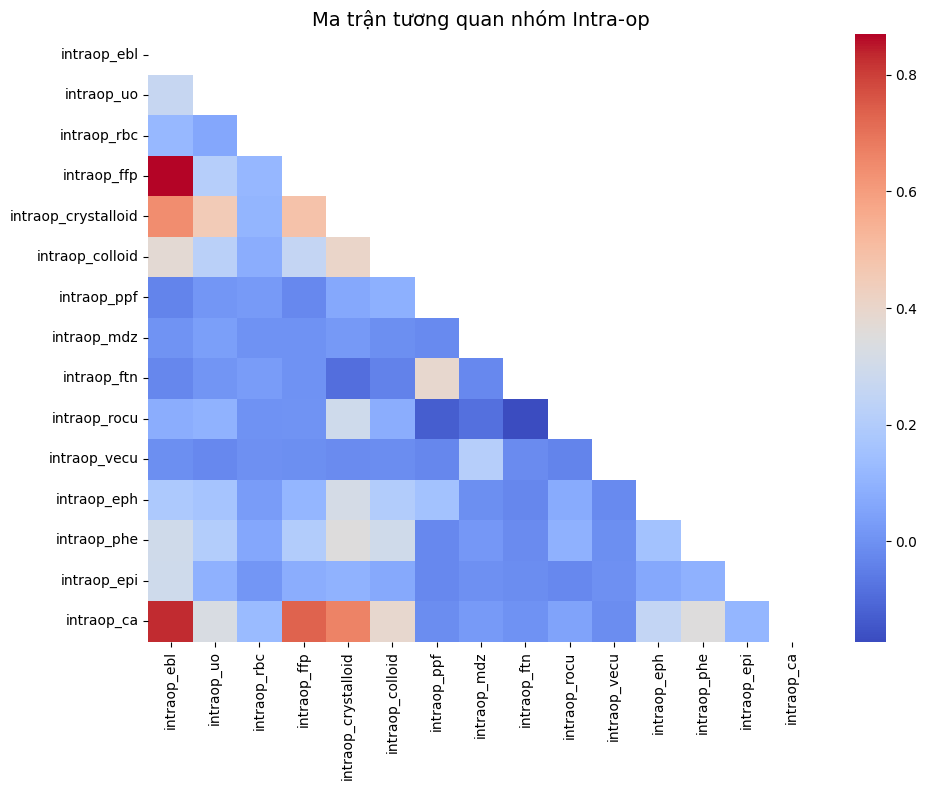

In [49]:
intraop_cols = [col for col in df.columns if col.startswith('intraop')]
corr_intraop = df[intraop_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_intraop, cmap='coolwarm', annot=False, mask=np.triu(np.ones_like(corr_intraop, dtype=bool)))
plt.title("Ma trận tương quan nhóm Intra-op", fontsize=14)
plt.tight_layout()
plt.show()

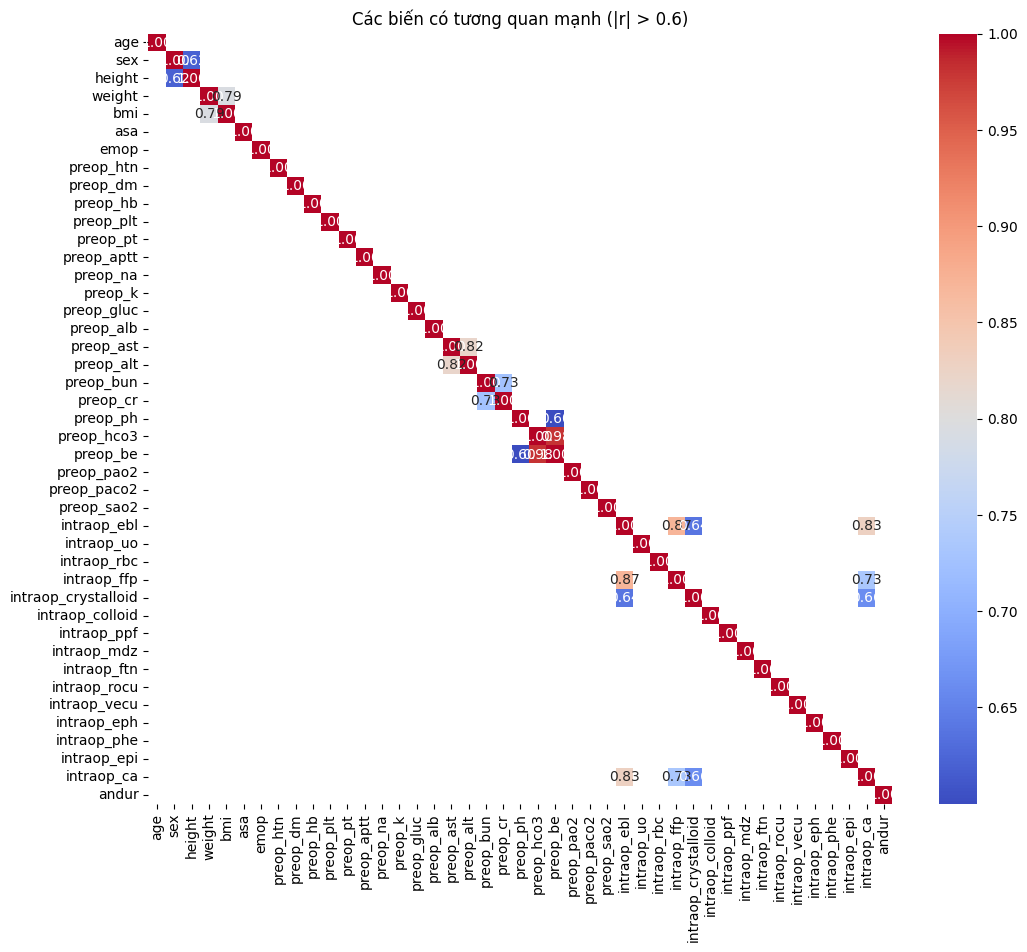

In [47]:
corr = df.corr().abs()
strong_corr = corr[corr > 0.6]
plt.figure(figsize=(12,10))
sns.heatmap(strong_corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Các biến có tương quan mạnh (|r| > 0.6)")
plt.show()
